Cell 1 — Imports + Config + Load dataset

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ---------------------------
# Configuration (reproducible setup)
# ---------------------------
DATA_DIR = r"D:\Irfan Jo\UTM\Semester 4\SAIA2133 Computer Vision\Individual project\garbage_classification"
IMG_SIZE = (224, 224)     # Standard input size (also matches EfficientNet expected resolution)
BATCH_SIZE = 32           # Batch processing for faster training
SEED = 42                 # Fixed seed for reproducible shuffling and splitting

# ---------------------------
# Load images from folder structure:
# garbage_classification/
#   battery/
#   brownglass/
#   cardboard/
# ---------------------------
# color_mode="grayscale" reduces input channels to 1:
# - Faster training, lower memory
# - Focuses more on shape/texture than colour variations due to lighting
all_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True,
    color_mode="grayscale"
)

# Class names are inferred from folder names
class_names = all_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)


Found 2443 files belonging to 3 classes.
Classes: ['battery', 'brown-glass', 'cardboard']


Cell 2 — Deterministic shuffle + train/val/test split

In [3]:
# Unbatch so we can split by individual samples (not by batches)
all_ds_unbatched = all_ds.unbatch()

# Shuffle ONCE deterministically (same split every run)
all_ds_unbatched = all_ds_unbatched.shuffle(
    buffer_size=2000,
    seed=SEED,
    reshuffle_each_iteration=False
)

# Count total samples to compute split sizes
card = all_ds_unbatched.cardinality().numpy()
if card < 0:
    # Some pipelines return unknown cardinality; this fallback counts manually
    card = sum(1 for _ in all_ds_unbatched)

n_total = int(card)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

# Split dataset:
# - take(): selects first N items
# - skip(): jumps over items already allocated
train_ds = all_ds_unbatched.take(n_train).batch(BATCH_SIZE)
val_ds   = all_ds_unbatched.skip(n_train).take(n_val).batch(BATCH_SIZE)
test_ds  = all_ds_unbatched.skip(n_train + n_val).take(n_test).batch(BATCH_SIZE)

print(f"Total: {n_total} | Train: {n_train} | Val: {n_val} | Test: {n_test}")

# Performance optimization:
# cache(): stores dataset in memory after first pass
# prefetch(): overlaps data loading with model training to reduce idle time
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)


Total: 2443 | Train: 1710 | Val: 366 | Test: 367


Cell 3 — EDA: class counts + bar chart + sample grid

Found 2443 files belonging to 3 classes.
Class counts: {'battery': 945, 'brown-glass': 607, 'cardboard': 891}


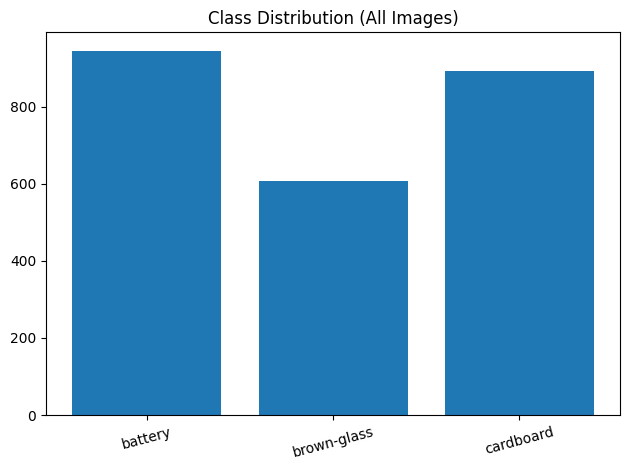

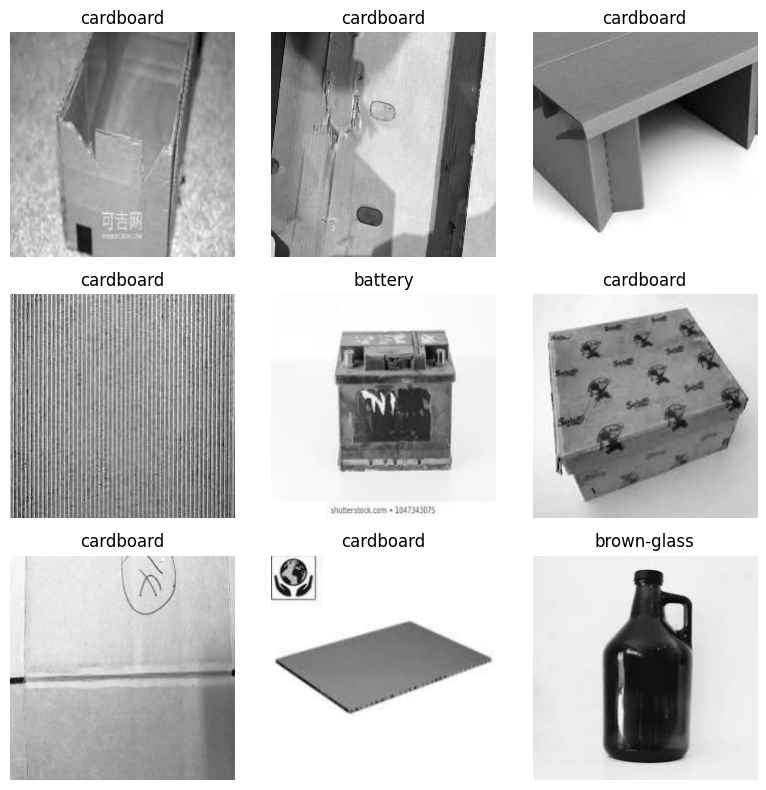

In [4]:
# Count labels to check class distribution (detect imbalance)
label_counter = Counter()
for _, labels in tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
):
    label_counter.update(labels.numpy().tolist())

counts = {class_names[k]: v for k, v in sorted(label_counter.items())}
print("Class counts:", counts)

# Bar chart: class distribution visualization
plt.figure()
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution (All Images)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Sample images grid from training set
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"), cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()


Cell 4 — Normalization + augmentation

In [5]:
# Normalization to [0,1] improves gradient stability
normalization = layers.Rescaling(1./255)

# Augmentation improves robustness & reduces overfitting
# Simulates real-world variations (angle, lighting, zoom)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomBrightness(0.15),
    layers.RandomZoom(0.10),
])

Cell 5 — Model A: Custom CNN (from scratch)

In [6]:
num_classes = 3

def build_custom_cnn():
    # Input is grayscale: (224,224,1)
    inputs = keras.Input(shape=(224, 224, 1))

    # Apply augmentation + normalization inside the model pipeline
    x = data_augmentation(inputs)
    x = normalization(x)

    # Conv blocks learn features: edges -> textures -> class patterns
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    # Dropout reduces overfitting on limited datasets
    x = layers.Dropout(0.3)(x)

    # Flatten + Dense perform final classification reasoning
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    # Softmax outputs probabilities for 3 classes
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

custom_model = build_custom_cnn()

# sparse_categorical_crossentropy is correct since labels are integers (0,1,2)
custom_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

custom_model.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,267 (12.46 MB)

 Trainable params: 3,267,267 (12.46 MB)

 Non-trainable params: 0 (0.00 B)

Cell 6 — Training callbacks + train custom model

In [7]:
# EarlyStopping prevents unnecessary epochs and keeps best weights
# ReduceLROnPlateau helps fine-tune if validation stops improving
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

history_custom = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
     54/Unknown 10s 164ms/step - accuracy: 0.4115 - loss: 1.1784

c:\Users\irfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


54/54 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.5000 - loss: 1.0358 - val_accuracy: 0.7022 - val_loss: 0.7931 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.6637 - loss: 0.7841 - val_accuracy: 0.7568 - val_loss: 0.6454 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 189ms/step - accuracy: 0.7058 - loss: 0.7023 - val_accuracy: 0.8142 - val_loss: 0.5130 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - accuracy: 0.7298 - loss: 0.6710 - val_accuracy: 0.7923 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.7462 - loss: 0.6174 - val_accuracy: 0.8169 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - accuracy: 0.7538 - loss: 0.6127 - val_accuracy: 0.8279 - val_loss: 0.4663 - learning_rate: 0.0010
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 10s 180ms/step - accuracy: 0.7737 - loss: 0.5694 - val_

Cell 7 — Model B: EfficientNetB0 transfer learning

In [8]:
def build_transfer_model():
    # EfficientNetB0: efficient and strong accuracy per parameter
    # include_top=False removes ImageNet classifier; we add our own head
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    # Freeze backbone to avoid overfitting and reduce training time
    base_model.trainable = False

    # Our input is grayscale (1 channel)
    inputs = keras.Input(shape=(224, 224, 1))

    # Augmentation
    x = data_augmentation(inputs)

    # EfficientNet expects a specific preprocessing to match ImageNet training distribution
    x = keras.applications.efficientnet.preprocess_input(x)

    # Use EfficientNet as a feature extractor
    x = base_model(x, training=False)

    # GAP reduces parameters and helps generalization
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Final classifier for 3 garbage classes
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="efficientnet_transfer"), base_model

transfer_model, base_model = build_transfer_model()

transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


Model: "efficientnet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Cell 8 — Train transfer model (EfficientNetB0)

In [9]:
history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.7819 - loss: 0.5456 - val_accuracy: 0.9727 - val_loss: 0.1729 - learning_rate: 0.0010
Epoch 2/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - accuracy: 0.9386 - loss: 0.2129 - val_accuracy: 0.9809 - val_loss: 0.1140 - learning_rate: 0.0010
Epoch 3/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.9556 - loss: 0.1523 - val_accuracy: 0.9809 - val_loss: 0.0916 - learning_rate: 0.0010
Epoch 4/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 244ms/step - accuracy: 0.9637 - loss: 0.1380 - val_accuracy: 0.9836 - val_loss: 0.0776 - learning_rate: 0.0010
Epoch 5/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 246ms/step - accuracy: 0.9620 - loss: 0.1166 - val_accuracy: 0.9891 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 6/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step - accuracy: 0.9667 - loss: 0.1111 - val_accuracy: 0.9891 - val_loss: 0.0622 - learning_rate: 0.0010
Epoch 7/10
54/54 ━━━━━━━━━━━━━━━━━━━━ 14s 261ms/step - accuracy: 0.9737 - loss: 0.

Cell 9 — Evaluation + confusion matrix


Custom CNN Classification Report
              precision    recall  f1-score   support

     battery     0.8322    0.8264    0.8293       144
  brownglass     0.8354    0.7765    0.8049        85
   cardboard     0.8483    0.8913    0.8693       138

    accuracy                         0.8392       367
   macro avg     0.8386    0.8314    0.8345       367
weighted avg     0.8390    0.8392    0.8387       367



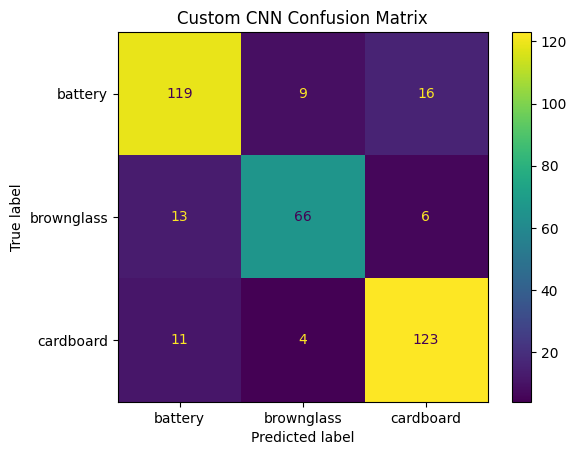

c:\Users\irfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Custom CNN Test Accuracy: 0.8392

EfficientNet Transfer Classification Report
              precision    recall  f1-score   support

     battery     0.9857    0.9583    0.9718       144
  brownglass     0.9659    1.0000    0.9827        85
   cardboard     0.9568    0.9638    0.9603       138

    accuracy                         0.9700       367
   macro avg     0.9695    0.9740    0.9716       367
weighted avg     0.9703    0.9700    0.9700       367



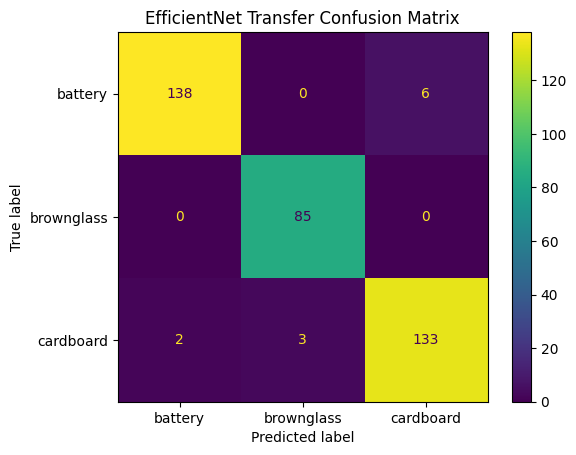

EfficientNet Transfer Test Accuracy: 0.9700


c:\Users\irfan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [10]:
CLASS_NAMES = ['battery', 'brownglass', 'cardboard']

def evaluate_model(model, name):
    y_true, y_pred = [], []

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    print(f"\n{name} Classification Report")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    loss, acc = model.evaluate(test_ds, verbose=0)
    print(f"{name} Test Accuracy: {acc:.4f}")

evaluate_model(custom_model, "Custom CNN")
evaluate_model(transfer_model, "EfficientNet Transfer")

Cell 10 — Visual demo: show test predictions

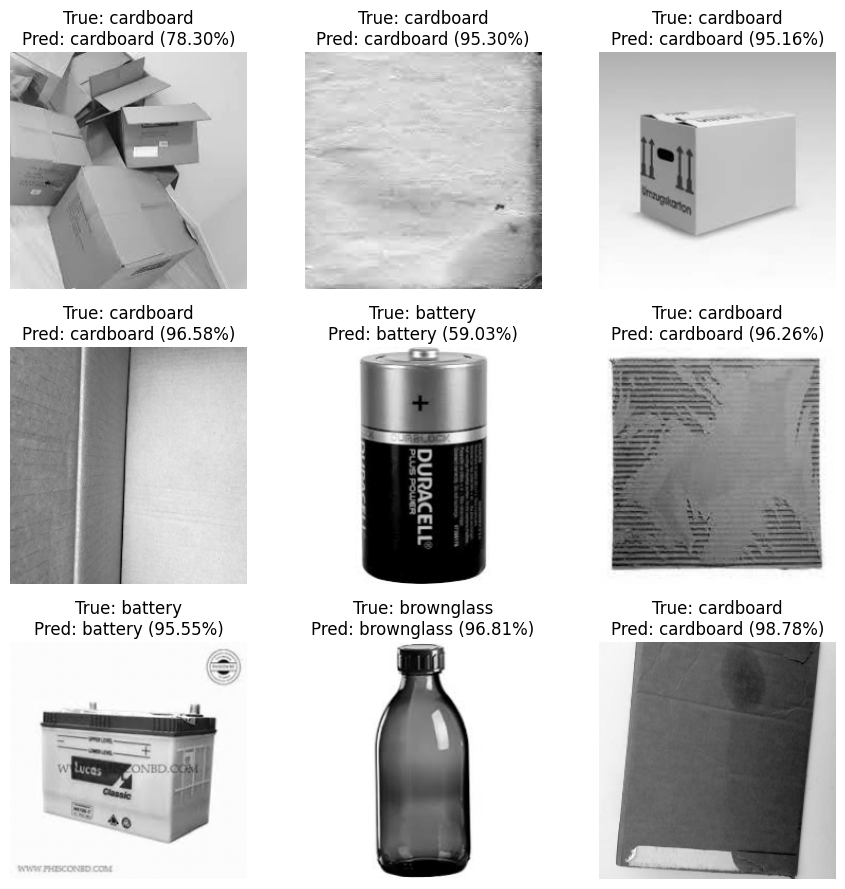

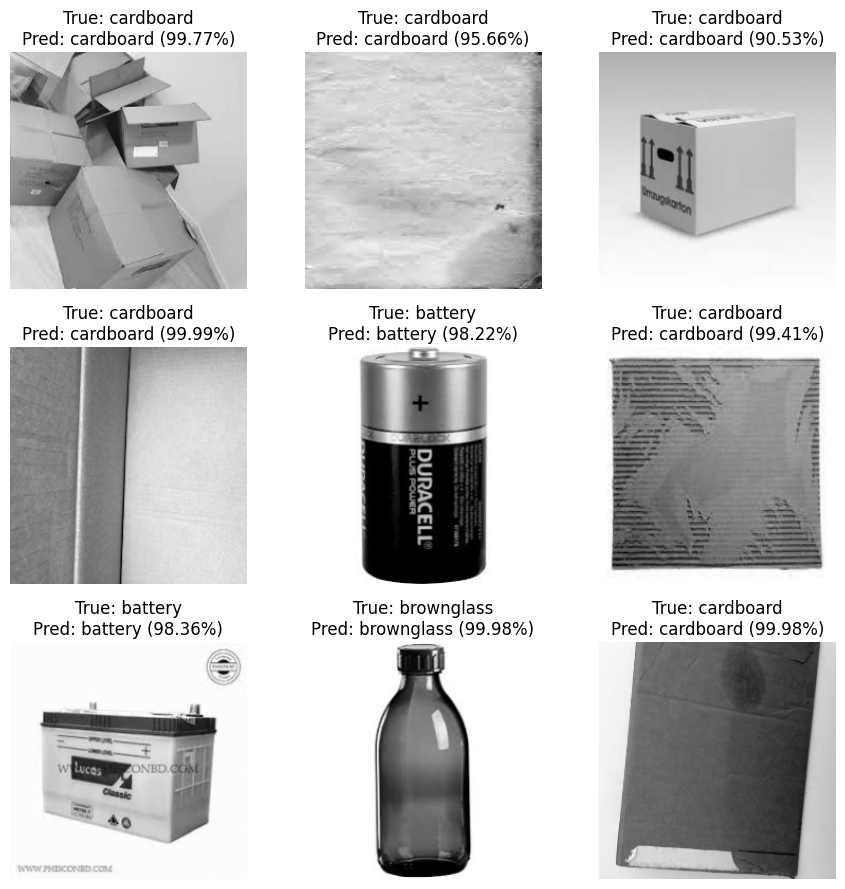

In [11]:
CLASS_NAMES = ['battery', 'brownglass', 'cardboard']

def show_test_predictions(model, test_ds, num_images=9):
    plt.figure(figsize=(9, 9))
    shown = 0

    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        confidences = np.max(preds, axis=1)

        for i in range(images.shape[0]):
            if shown >= num_images:
                break

            plt.subplot(3, 3, shown + 1)
            plt.imshow(images[i].numpy().squeeze(), cmap="gray")

            true_label = CLASS_NAMES[int(labels[i])]
            pred_label = CLASS_NAMES[int(pred_classes[i])]
            conf = float(confidences[i])

            plt.title(f"True: {true_label}\nPred: {pred_label} ({conf:.2%})")
            plt.axis("off")

            shown += 1

        if shown >= num_images:
            break

    plt.tight_layout()
    plt.show()

show_test_predictions(custom_model, test_ds)
show_test_predictions(transfer_model, test_ds)
